<a href="https://colab.research.google.com/github/prajwalbhandari416/Geomagnetic-Storms/blob/main/BiLSTM_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.20.0


GEOMAGNETIC STORM PREDICTION USING BiLSTM
Targets: Kp × 10 and Dst


LOADING DATA

Original dataset shape: (21734, 15)

Original columns:
['YEAR', 'DOY', 'HR', 'B', 'Bx', 'By', 'Bz', 'PD', 'FP', 'E', 'Kp', 'Dst', 'AE', 'AU', 'AL']

Normalized columns:
['YEAR', 'DOY', 'HR', 'B', 'Bx', 'By', 'Bz', 'PD', 'FP', 'E', 'Kp', 'Dst', 'AE', 'AU', 'AL']

All required columns found.


HANDLING MISSING VALUES
PD: replaced 1909 values of 999.9
FP: replaced 1909 values of 99.99
E: replaced 2070 values of 999.99


CLEANING DATA

Missing values before processing:
PD     1909
FP     1909
E      2070
Dst       1
dtype: int64

Rows removed because of missing Kp/Dst targets: 1
Rows removed after final cleaning: 0

Detected Kp range: 0.0000 to 83.0000

Kp appears to already be Kp × 10.

Final columns:
['YEAR', 'DOY', 'HR', 'B', 'Bx', 'By', 'Bz', 'PD', 'FP', 'E', 'Kp10', 'Dst']

Final dataset shape: (21733, 12)

Kp × 10 statistics:
count    21733.000000
mean        24.363456
std 

Model: "BiLSTM_Geomagnetic_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 48, 10)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiLSTM_1            │ (None, 48, 128)   │     38,400 │ Input[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dropout_1 (Dropout) │ (None, 48, 128)   │          0 │ BiLSTM_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BiLSTM_2            │ (None, 64)        │     41,216 │ Dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dropout_2 (Dropout) │ (None, 64)        │          0 │ BiLSTM_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense_64 (Dense)    │ (None, 64)        │      4,160 │ Dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dropout_3 (Dropout) │ (None, 64)        │          0 │ Dense_64[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Kp10 (Dense)        │ (None, 1)         │         65 │ Dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dst (Dense)         │ (None, 1)         │         65 │ Dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 83,906 (327.76 KB)

 Trainable params: 83,906 (327.76 KB)

 Non-trainable params: 0 (0.00 B)


Model summary saved to:
/content/geomagnetic_BiLSTM_results/BiLSTM_model_summary.txt


TRAINING BiLSTM
Epoch 1/100
440/440 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - Dst_loss: 0.0472 - Dst_mae: 0.1574 - Kp10_loss: 0.0342 - Kp10_mae: 0.1469 - loss: 0.0813
Epoch 1: val_loss improved from None to 0.03340, saving model to /content/geomagnetic_BiLSTM_results/BiLSTM_best.keras

Epoch 1: finished saving model to /content/geomagnetic_BiLSTM_results/BiLSTM_best.keras
440/440 ━━━━━━━━━━━━━━━━━━━━ 52s 100ms/step - Dst_loss: 0.0257 - Dst_mae: 0.1213 - Kp10_loss: 0.0317 - Kp10_mae: 0.1409 - loss: 0.0574 - val_Dst_loss: 0.0068 - val_Dst_mae: 0.0683 - val_Kp10_loss: 0.0266 - val_Kp10_mae: 0.1316 - val_loss: 0.0334 - learning_rate: 0.0010
Epoch 2/100
440/440 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - Dst_loss: 0.0139 - Dst_mae: 0.0935 - Kp10_loss: 0.0265 - Kp10_mae: 0.1303 - loss: 0.0405
Epoch 2: val_loss improved from 0.03340 to 0.03288, saving model to /content/geomagnetic_BiLSTM_results/BiLSTM_best.keras

Epoch

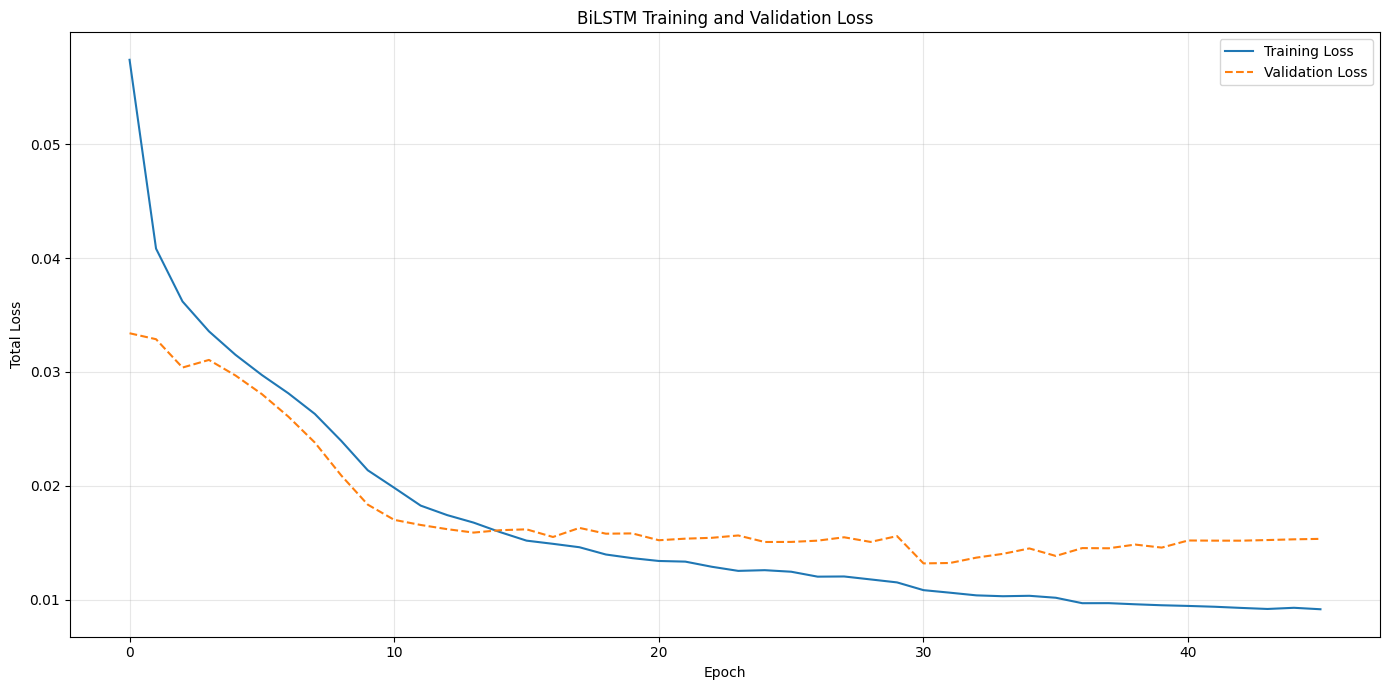

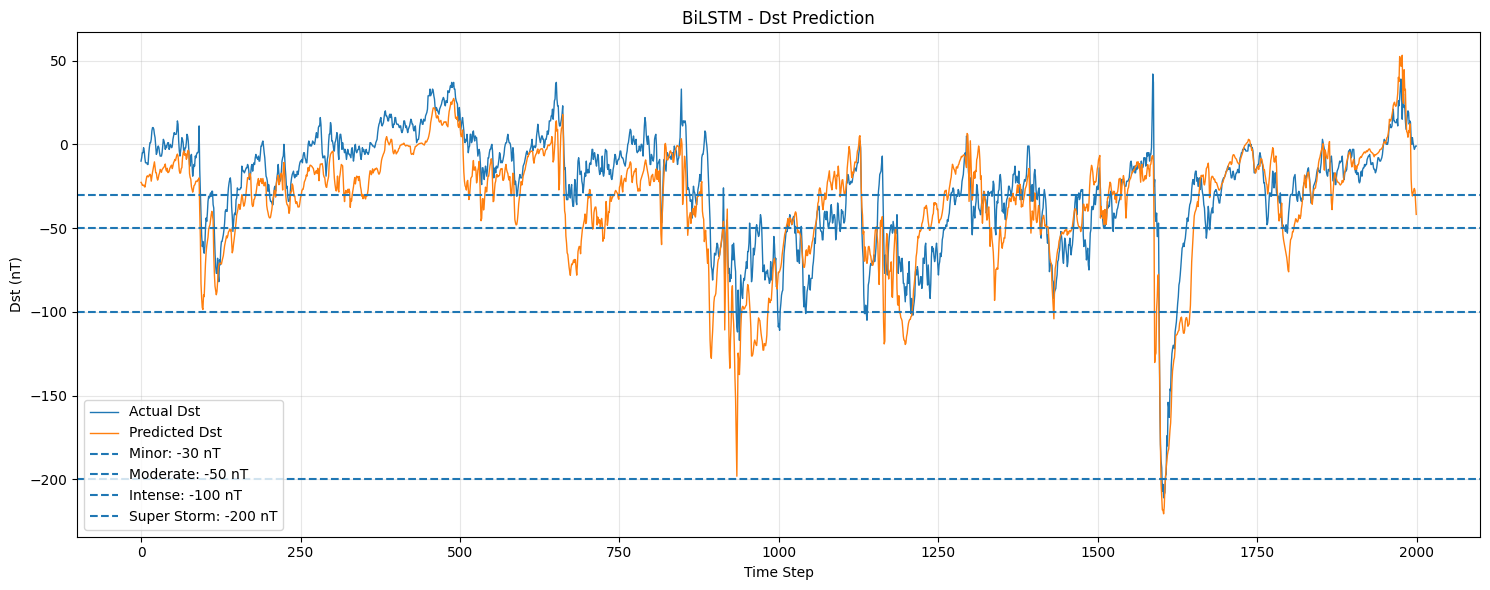

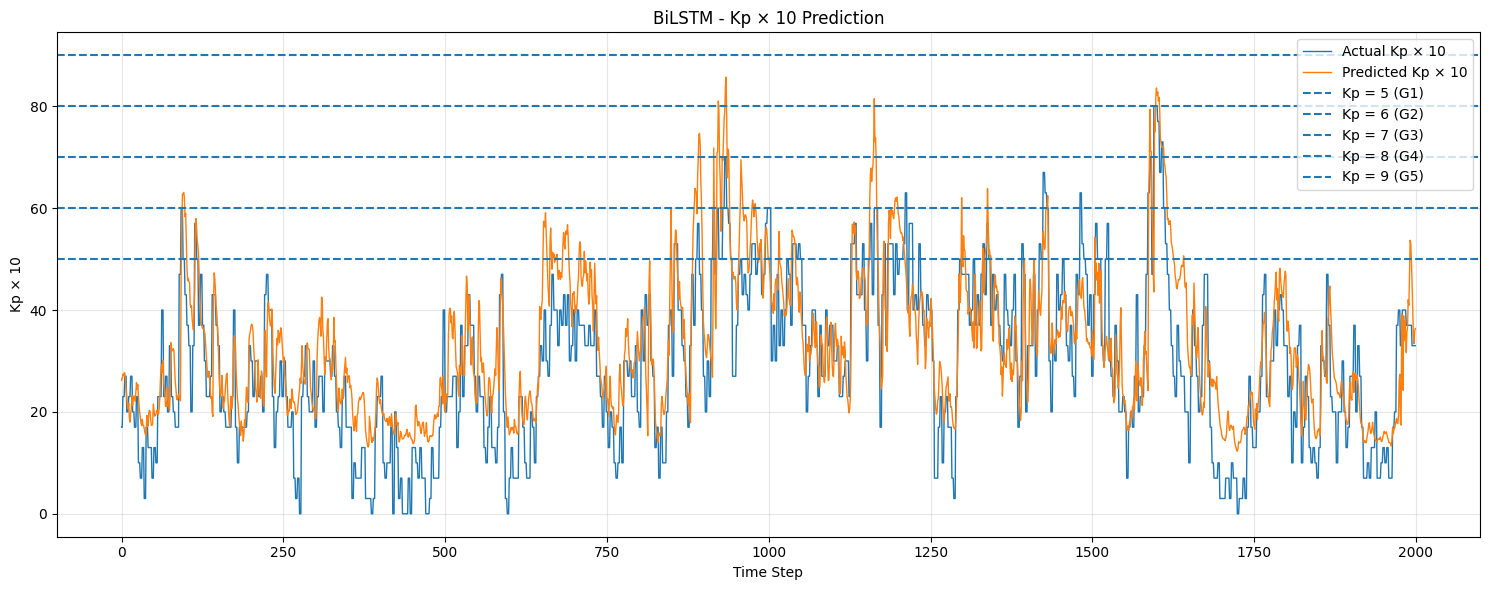

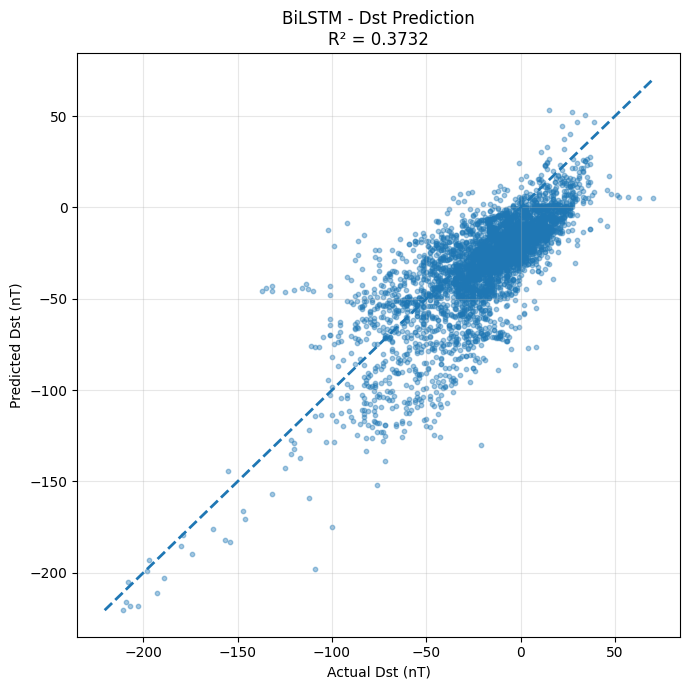

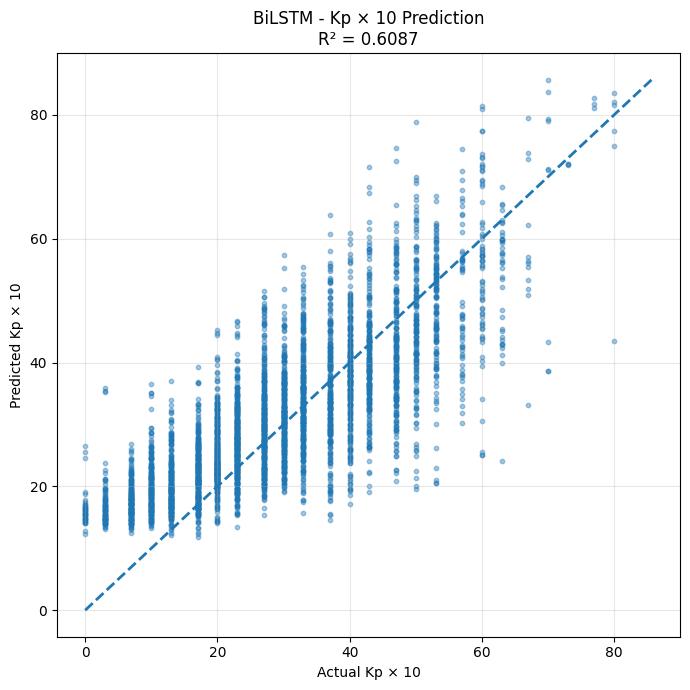

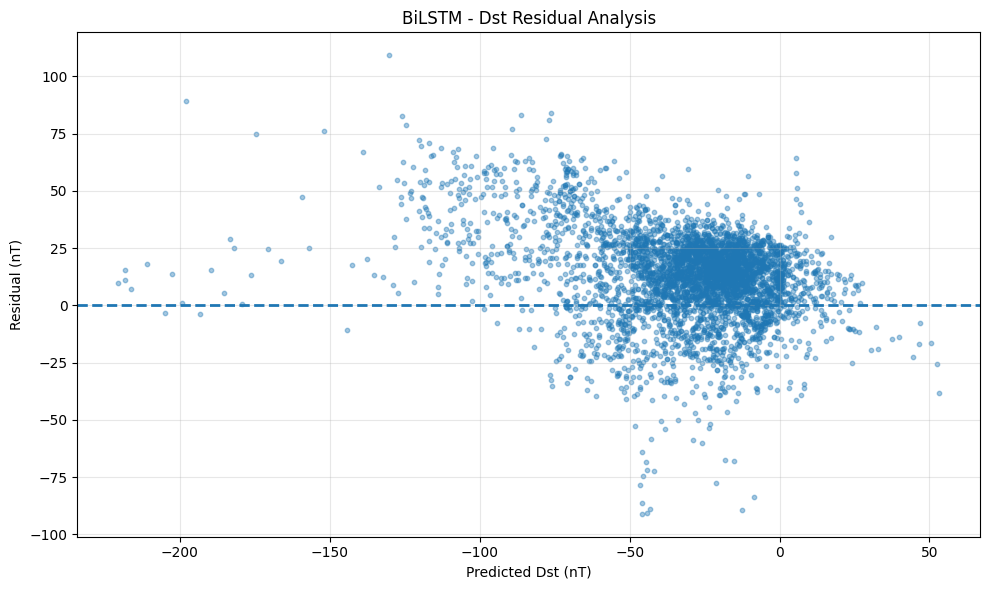

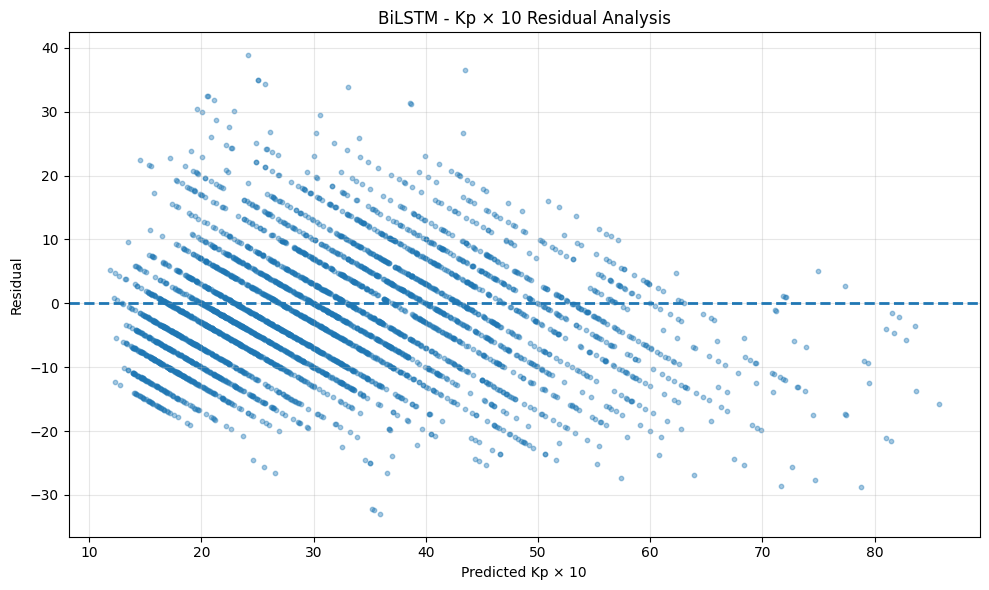

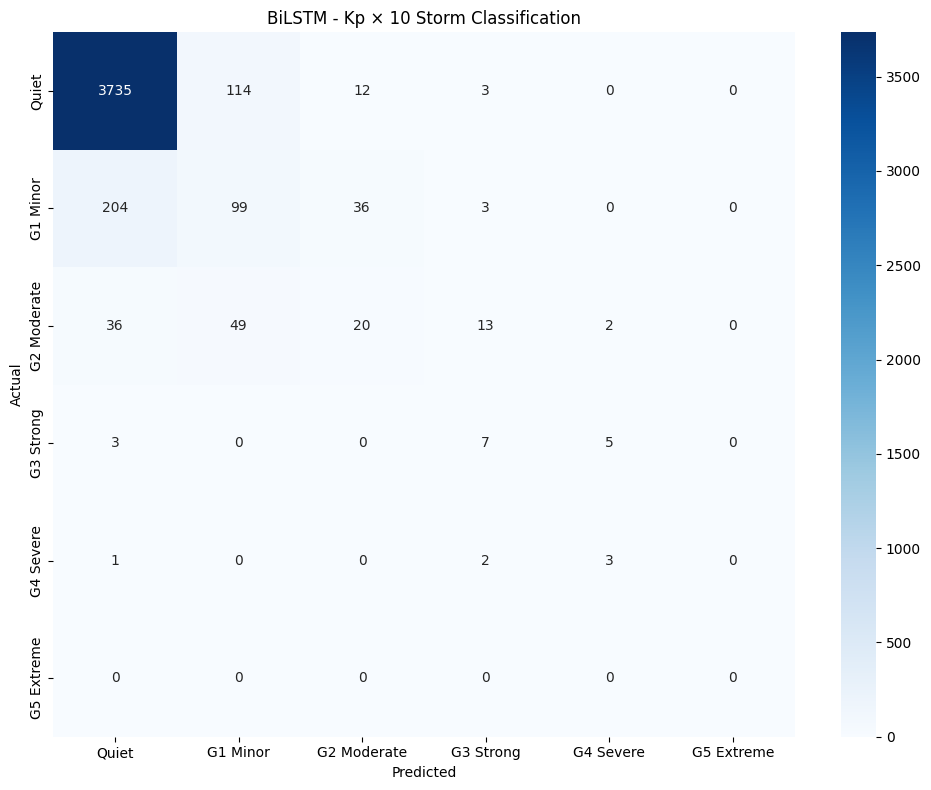

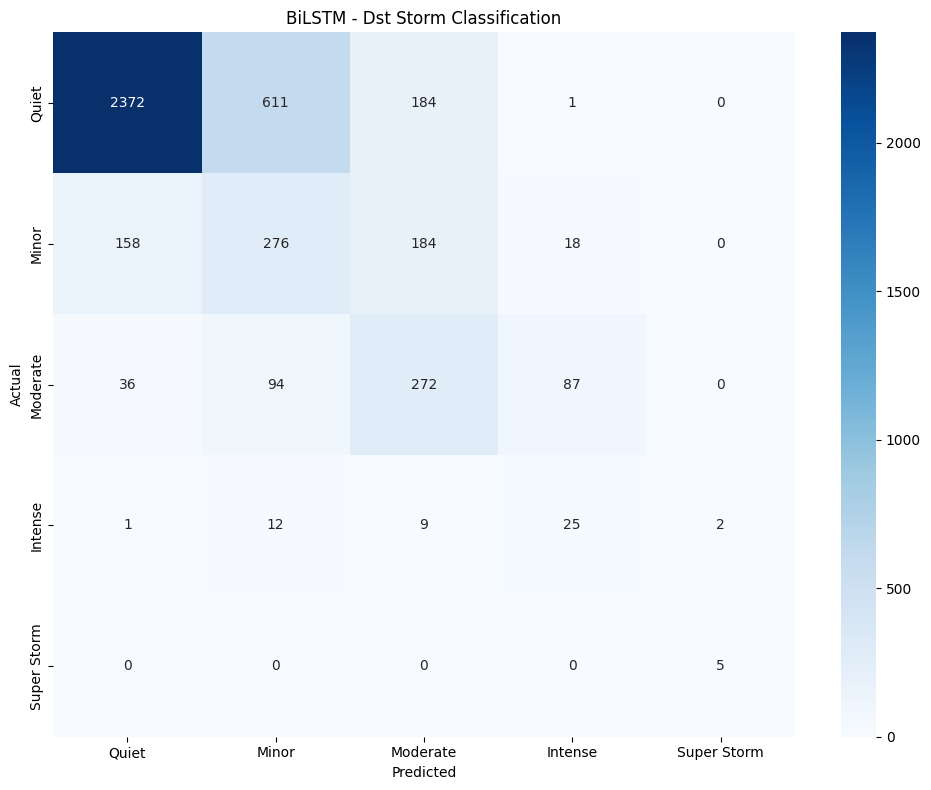

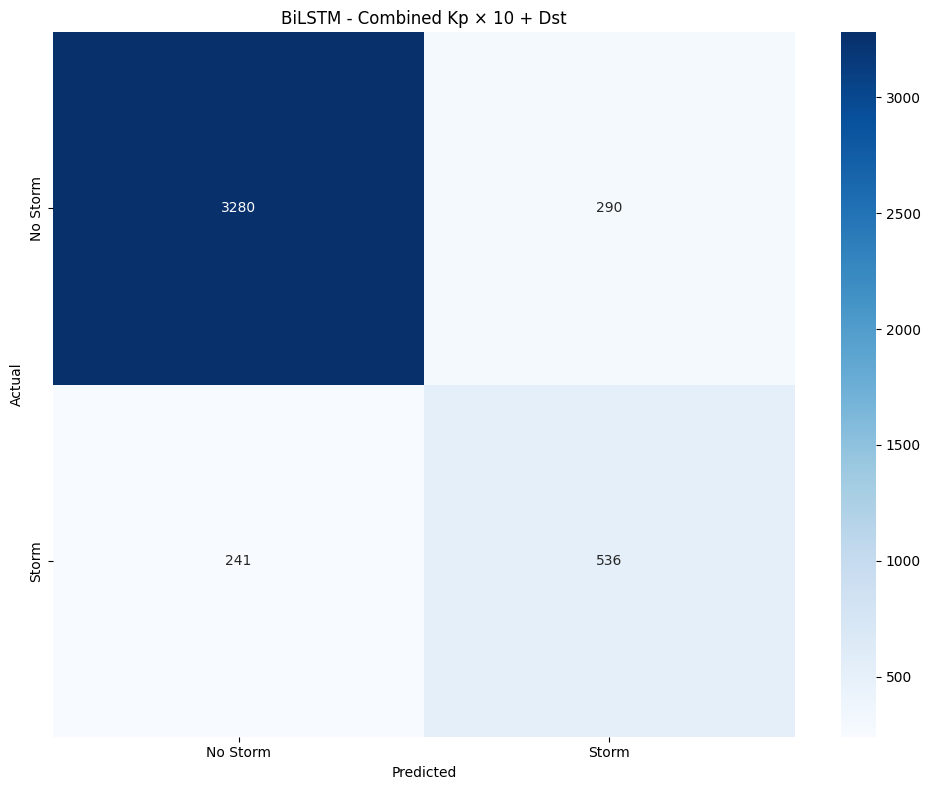

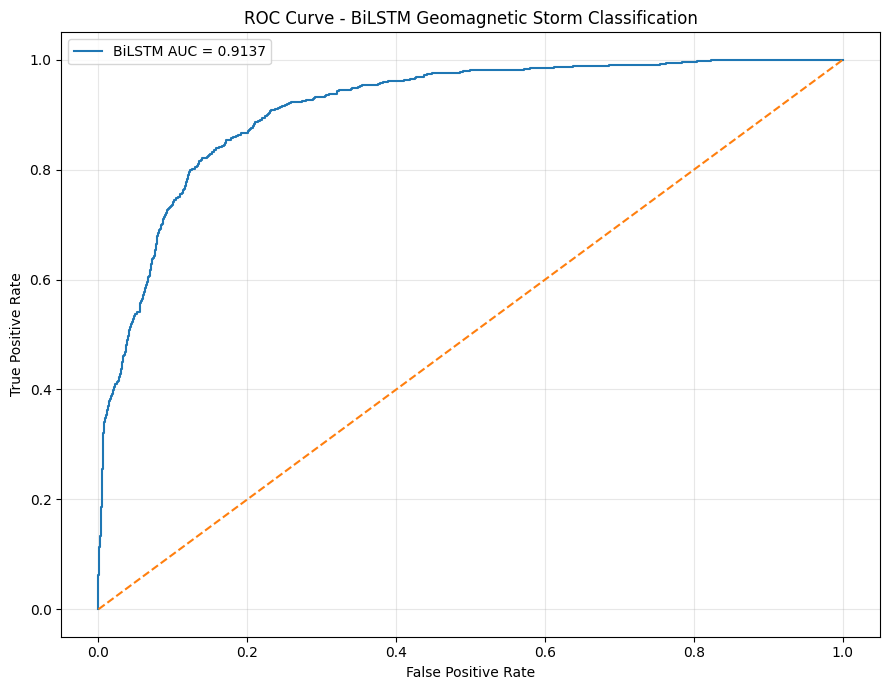

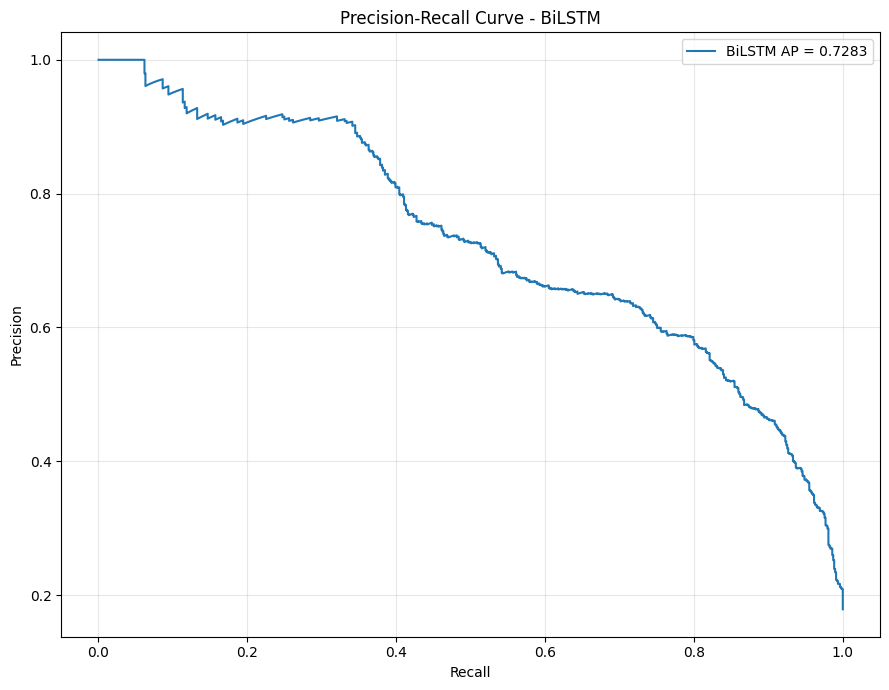


Predictions saved to:
/content/geomagnetic_BiLSTM_results/BiLSTM_predictions.csv

Metrics saved to:
/content/geomagnetic_BiLSTM_results/BiLSTM_metrics.csv


FINAL BiLSTM RESULTS


Kp × 10:
RMSE        = 9.2438
MAE         = 7.3610
R²          = 0.6087
Correlation = 0.7968


Dst:
RMSE        = 23.1427 nT
MAE         = 18.7125 nT
R²          = 0.3732
Correlation = 0.7792
PE          = 0.5477


Storm Classification:
Kp × 10 Accuracy = 0.8889
Dst Accuracy      = 0.6786
Combined Accuracy = 0.8778
Combined Precision = 0.6489
Combined Recall = 0.6898
Combined F1 = 0.6687


RESULTS SAVED
/content/geomagnetic_BiLSTM_results

Files generated:
1. cleaned_geomagnetic_data.csv
2. BiLSTM_best.keras
3. BiLSTM_predictions.csv
4. BiLSTM_metrics.csv
5. BiLSTM_training_history.csv
6. BiLSTM_model_summary.txt
7. BiLSTM_training_validation_loss.png
8. BiLSTM_Dst_prediction.png
9. BiLSTM_Kp10_prediction.png
10. BiLSTM_Dst_scatter.png
11. BiLSTM_Kp10_scatter.png
12. BiLSTM_Dst_residuals.png
13. BiLSTM_Kp10_

In [ ]:

# ============================================================
# GEOMAGNETIC STORM PREDICTION USING BiLSTM
# Based on Kp × 10 and Dst
#
# Author: Prajwal Bhandari
# Date: September 2026
#
# MODEL:
#   BiLSTM
#
# TARGETS:
#   1. Kp × 10
#   2. Dst
#
# INPUT FEATURES:
#   YEAR, DOY, HR, B, Bx, By, Bz, PD, FP, E
#
# LOOKBACK:
#   48 hours
#
# ============================================================


# ============================================================
# 0. IMPORT LIBRARIES
# ============================================================

import os
import re
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

import tensorflow as tf

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


# ============================================================
# 2. CONFIGURATION
# ============================================================

# ------------------------------------------------------------
# Dataset path
# ------------------------------------------------------------
DATA_PATH = "Sun.csv"

# If using Google Colab and file is in /content:
# DATA_PATH = "/content/Sun.csv"


# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

OUTPUT_DIR = "/content/geomagnetic_BiLSTM_results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# Time-series configuration
# ------------------------------------------------------------

LOOKBACK = 48

TEST_SIZE = 0.20

VALIDATION_SIZE = 0.15

EPOCHS = 100

BATCH_SIZE = 32

LEARNING_RATE = 0.001


# ------------------------------------------------------------
# BiLSTM configuration
# ------------------------------------------------------------

BILSTM_UNITS_1 = 64

BILSTM_UNITS_2 = 32

DROPOUT = 0.20


# ============================================================
# 3. COLUMN DEFINITIONS
# ============================================================

EXPECTED_COLUMNS = [
    "YEAR",
    "DOY",
    "HR",
    "B",
    "Bx",
    "By",
    "Bz",
    "PD",
    "FP",
    "E",
    "Kp",
    "Dst"
]


# ============================================================
# 4. DATA PREPROCESSOR
# ============================================================

class DataPreprocessor:
    """
    Loads, cleans and prepares geomagnetic data.
    """

    def __init__(self, filepath):

        self.filepath = filepath

        self.df = None

        self.missing_values_map = {

            "B": [
                999.99,
                9999.99
            ],

            "Bx": [
                999.99,
                9999.99
            ],

            "By": [
                999.99,
                9999.99
            ],

            "Bz": [
                999.99,
                9999.99
            ],

            "PD": [
                999.9,
                999.99,
                9999.9
            ],

            "FP": [
                99.99,
                999.99
            ],

            "E": [
                999.99,
                9999.99
            ],

            "Kp": [
                9.99,
                99.99
            ],

            "Dst": [
                9999.9,
                9999.99
            ]
        }


    # ========================================================
    # Normalize column names
    # ========================================================

    def normalize_column_names(self):

        new_columns = []

        for col in self.df.columns:

            col_clean = str(col).strip()

            col_clean = re.sub(
                r"\s+",
                " ",
                col_clean
            )

            lower_col = col_clean.lower()

            # Kp variants
            if "kp" in lower_col:

                col_clean = "Kp"

            elif lower_col == "dst":

                col_clean = "Dst"

            new_columns.append(
                col_clean
            )

        self.df.columns = new_columns

        return self


    # ========================================================
    # Load data
    # ========================================================

    def load_data(self):

        print("\n")
        print("=" * 80)
        print("LOADING DATA")
        print("=" * 80)

        if not os.path.exists(self.filepath):

            raise FileNotFoundError(
                f"\nDataset not found:\n{self.filepath}\n\n"
                f"Please check DATA_PATH."
            )

        self.df = pd.read_csv(
            self.filepath
        )

        print(
            "\nOriginal dataset shape:",
            self.df.shape
        )

        print(
            "\nOriginal columns:"
        )

        print(
            list(self.df.columns)
        )

        self.normalize_column_names()

        print(
            "\nNormalized columns:"
        )

        print(
            list(self.df.columns)
        )

        return self


    # ========================================================
    # Check required columns
    # ========================================================

    def check_columns(self):

        missing = [
            col
            for col in EXPECTED_COLUMNS
            if col not in self.df.columns
        ]

        if len(missing) > 0:

            raise ValueError(
                "\nMissing required columns:\n"
                + str(missing)
                + "\n\nAvailable columns:\n"
                + str(list(self.df.columns))
            )

        print(
            "\nAll required columns found."
        )

        return self


    # ========================================================
    # Handle missing values
    # ========================================================

    def handle_missing_values(self):

        print("\n")
        print("=" * 80)
        print("HANDLING MISSING VALUES")
        print("=" * 80)

        for col, values in self.missing_values_map.items():

            if col in self.df.columns:

                for value in values:

                    count = (
                        self.df[col] == value
                    ).sum()

                    if count > 0:

                        self.df[col] = (
                            self.df[col]
                            .replace(
                                value,
                                np.nan
                            )
                        )

                        print(
                            f"{col}: replaced "
                            f"{count} values of {value}"
                        )

        return self


    # ========================================================
    # Clean data
    # ========================================================

    def clean_data(self):

        print("\n")
        print("=" * 80)
        print("CLEANING DATA")
        print("=" * 80)


        # ----------------------------------------------------
        # Convert all required columns to numeric
        # ----------------------------------------------------

        for col in EXPECTED_COLUMNS:

            self.df[col] = pd.to_numeric(
                self.df[col],
                errors="coerce"
            )


        # ----------------------------------------------------
        # Sort chronologically
        # ----------------------------------------------------

        self.df = (
            self.df
            .sort_values(
                [
                    "YEAR",
                    "DOY",
                    "HR"
                ]
            )
            .reset_index(
                drop=True
            )
        )


        print(
            "\nMissing values before processing:"
        )

        missing = self.df.isna().sum()

        print(
            missing[
                missing > 0
            ]
        )


        # ----------------------------------------------------
        # Interpolate input variables
        # ----------------------------------------------------

        input_columns = [
            "YEAR",
            "DOY",
            "HR",
            "B",
            "Bx",
            "By",
            "Bz",
            "PD",
            "FP",
            "E"
        ]

        self.df[input_columns] = (
            self.df[input_columns]
            .interpolate(
                method="linear"
            )
            .ffill()
            .bfill()
        )


        # ----------------------------------------------------
        # Do NOT interpolate target values
        #
        # Missing Kp and Dst target observations are removed.
        # This is safer for supervised storm prediction.
        # ----------------------------------------------------

        before_targets = len(self.df)

        self.df = self.df.dropna(
            subset=[
                "Kp",
                "Dst"
            ]
        )

        after_targets = len(self.df)

        print(
            f"\nRows removed because of missing "
            f"Kp/Dst targets: "
            f"{before_targets - after_targets}"
        )


        # ----------------------------------------------------
        # Remove remaining missing values
        # ----------------------------------------------------

        before = len(self.df)

        self.df = self.df.dropna()

        after = len(self.df)

        print(
            f"Rows removed after final cleaning: "
            f"{before - after}"
        )


        # ----------------------------------------------------
        # CREATE Kp × 10
        # ----------------------------------------------------

        kp_max = self.df["Kp"].max()

        kp_min = self.df["Kp"].min()

        print(
            f"\nDetected Kp range: "
            f"{kp_min:.4f} to {kp_max:.4f}"
        )


        if kp_max <= 9.0:

            print(
                "\nKp detected as standard 0–9 scale."
            )

            print(
                "Creating Kp10 = Kp × 10."
            )

            self.df["Kp10"] = (
                self.df["Kp"] * 10.0
            )

        else:

            print(
                "\nKp appears to already be Kp × 10."
            )

            self.df["Kp10"] = (
                self.df["Kp"]
            )


        # ----------------------------------------------------
        # Remove original Kp
        # ----------------------------------------------------

        self.df.drop(
            columns=["Kp"],
            inplace=True
        )


        # ----------------------------------------------------
        # Final columns
        # ----------------------------------------------------

        final_columns = [

            "YEAR",
            "DOY",
            "HR",

            "B",
            "Bx",
            "By",
            "Bz",

            "PD",
            "FP",
            "E",

            "Kp10",
            "Dst"
        ]

        self.df = self.df[
            final_columns
        ]


        # ----------------------------------------------------
        # Reset index
        # ----------------------------------------------------

        self.df = self.df.reset_index(
            drop=True
        )


        print(
            "\nFinal columns:"
        )

        print(
            list(self.df.columns)
        )


        print(
            "\nFinal dataset shape:",
            self.df.shape
        )


        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        print(
            "\nKp × 10 statistics:"
        )

        print(
            self.df["Kp10"].describe()
        )


        print(
            "\nDst statistics:"
        )

        print(
            self.df["Dst"].describe()
        )


        return self


    # ========================================================
    # Return processed data
    # ========================================================

    def get_processed_data(self):

        return self.df


# ============================================================
# 5. SEQUENCE GENERATOR
# ============================================================

class SequenceGenerator:
    """
    Creates 48-hour sequences.

    Features:
        YEAR, DOY, HR,
        B, Bx, By, Bz,
        PD, FP, E

    Targets:
        Kp10
        Dst

    The validation and test sequences use the previous
    LOOKBACK observations as historical context.
    """

    def __init__(
        self,
        data,
        lookback=48
    ):

        self.data = data.copy()

        self.lookback = lookback


        self.feature_columns = [

            "YEAR",
            "DOY",
            "HR",

            "B",
            "Bx",
            "By",
            "Bz",

            "PD",
            "FP",
            "E"
        ]


        self.target_columns = [

            "Kp10",
            "Dst"
        ]


        self.feature_scaler = MinMaxScaler()

        self.target_scaler = MinMaxScaler()


    # ========================================================
    # Prepare chronological split
    # ========================================================

    def split_raw_data(
        self,
        test_size=0.20,
        val_size=0.15
    ):

        if test_size + val_size >= 1.0:

            raise ValueError(
                "TEST_SIZE + VALIDATION_SIZE "
                "must be less than 1.0"
            )


        n = len(self.data)


        # ----------------------------------------------------
        # Exact chronological split
        #
        # 65% train
        # 15% validation
        # 20% test
        # ----------------------------------------------------

        train_end = int(
            n * (1.0 - test_size - val_size)
        )

        val_end = int(
            n * (1.0 - test_size)
        )


        train_df = self.data[
            :train_end
        ].copy()


        val_df = self.data[
            train_end:val_end
        ].copy()


        test_df = self.data[
            val_end:
        ].copy()


        print("\n")
        print("=" * 80)
        print("RAW CHRONOLOGICAL SPLIT")
        print("=" * 80)

        print(
            f"Training rows:   {len(train_df):,}"
        )

        print(
            f"Validation rows: {len(val_df):,}"
        )

        print(
            f"Testing rows:    {len(test_df):,}"
        )


        return (
            train_df,
            val_df,
            test_df
        )


    # ========================================================
    # Fit scalers on training data only
    # ========================================================

    def fit_scalers(
        self,
        train_df
    ):

        self.feature_scaler.fit(
            train_df[
                self.feature_columns
            ]
        )


        self.target_scaler.fit(
            train_df[
                self.target_columns
            ]
        )


        print(
            "\nFeature and target scalers "
            "fitted using TRAINING data only."
        )


    # ========================================================
    # Transform dataframe
    # ========================================================

    def transform_data(
        self,
        df
    ):

        X_scaled = (
            self.feature_scaler.transform(
                df[
                    self.feature_columns
                ]
            )
        )


        y_scaled = (
            self.target_scaler.transform(
                df[
                    self.target_columns
                ]
            )
        )


        return (
            X_scaled,
            y_scaled
        )


    # ========================================================
    # Create sequences
    # ========================================================

    def create_sequences_from_arrays(
        self,
        X_scaled,
        y_scaled
    ):

        X = []
        y = []


        for i in range(
            self.lookback,
            len(X_scaled)
        ):

            X.append(
                X_scaled[
                    i - self.lookback:i
                ]
            )

            y.append(
                y_scaled[i]
            )


        X = np.asarray(
            X,
            dtype=np.float32
        )

        y = np.asarray(
            y,
            dtype=np.float32
        )


        return (
            X,
            y
        )


    # ========================================================
    # Prepare train/validation/test sequences
    # ========================================================

    def prepare_data(
        self,
        test_size=0.20,
        val_size=0.15
    ):

        (
            train_df,
            val_df,
            test_df
        ) = self.split_raw_data(
            test_size,
            val_size
        )


        train_end = len(
            train_df
        )

        val_end = (
            train_end
            +
            len(val_df)
        )


        # ----------------------------------------------------
        # Fit scalers ONLY using training data
        # ----------------------------------------------------

        self.fit_scalers(
            train_df
        )


        # ====================================================
        # TRAIN DATA
        # ====================================================

        X_train_scaled, y_train_scaled = (
            self.transform_data(
                train_df
            )
        )


        X_train, y_train = (
            self.create_sequences_from_arrays(
                X_train_scaled,
                y_train_scaled
            )
        )


        # ====================================================
        # VALIDATION DATA
        #
        # Add 48 historical observations before validation.
        # ====================================================

        val_start_with_context = max(
            0,
            train_end - self.lookback
        )


        val_context = self.data[
            val_start_with_context:val_end
        ].copy()


        X_val_context, y_val_context = (
            self.transform_data(
                val_context
            )
        )


        X_val_all, y_val_all = (
            self.create_sequences_from_arrays(
                X_val_context,
                y_val_context
            )
        )


        # The first LOOKBACK sequence corresponds to
        # the first validation target.
        X_val = X_val_all
        y_val = y_val_all


        # ====================================================
        # TEST DATA
        #
        # Add 48 historical observations before test.
        # ====================================================

        test_start_with_context = max(
            0,
            val_end - self.lookback
        )


        test_context = self.data[
            test_start_with_context:
        ].copy()


        X_test_context, y_test_context = (
            self.transform_data(
                test_context
            )
        )


        X_test_all, y_test_all = (
            self.create_sequences_from_arrays(
                X_test_context,
                y_test_context
            )
        )


        X_test = X_test_all
        y_test = y_test_all


        # ====================================================
        # CHECK SHAPES
        # ====================================================

        print("\n")
        print("=" * 80)
        print("SEQUENCE DATA")
        print("=" * 80)

        print(
            "X_train:",
            X_train.shape
        )

        print(
            "y_train:",
            y_train.shape
        )

        print(
            "X_val:",
            X_val.shape
        )

        print(
            "y_val:",
            y_val.shape
        )

        print(
            "X_test:",
            X_test.shape
        )

        print(
            "y_test:",
            y_test.shape
        )


        if len(X_train) == 0:

            raise ValueError(
                "Training sequences are empty. "
                "Check dataset size and LOOKBACK."
            )


        if len(X_val) == 0:

            raise ValueError(
                "Validation sequences are empty. "
                "Check dataset size and LOOKBACK."
            )


        if len(X_test) == 0:

            raise ValueError(
                "Test sequences are empty. "
                "Check dataset size and LOOKBACK."
            )


        return (
            X_train,
            X_val,
            X_test,
            y_train,
            y_val,
            y_test
        )


# ============================================================
# 6. BiLSTM MODEL
# ============================================================

class BiLSTMModel:

    @staticmethod
    def build(
        input_shape,
        units1=64,
        units2=32,
        dropout=0.20
    ):

        inputs = Input(
            shape=input_shape,
            name="Input"
        )


        # ----------------------------------------------------
        # First BiLSTM
        # ----------------------------------------------------

        x = Bidirectional(
            LSTM(
                units1,
                return_sequences=True
            ),
            name="BiLSTM_1"
        )(inputs)


        x = Dropout(
            dropout,
            name="Dropout_1"
        )(x)


        # ----------------------------------------------------
        # Second BiLSTM
        # ----------------------------------------------------

        x = Bidirectional(
            LSTM(
                units2,
                return_sequences=False
            ),
            name="BiLSTM_2"
        )(x)


        x = Dropout(
            dropout,
            name="Dropout_2"
        )(x)


        # ----------------------------------------------------
        # Dense
        # ----------------------------------------------------

        x = Dense(
            64,
            activation="relu",
            name="Dense_64"
        )(x)


        x = Dropout(
            dropout,
            name="Dropout_3"
        )(x)


        # ====================================================
        # Kp × 10 OUTPUT
        # ====================================================

        kp_output = Dense(
            1,
            name="Kp10"
        )(x)


        # ====================================================
        # Dst OUTPUT
        # ====================================================

        dst_output = Dense(
            1,
            name="Dst"
        )(x)


        # ====================================================
        # FINAL MODEL
        # ====================================================

        model = Model(
            inputs=inputs,
            outputs=[
                kp_output,
                dst_output
            ],
            name="BiLSTM_Geomagnetic_Model"
        )


        return model


# ============================================================
# 7. BiLSTM TRAINER
# ============================================================

class BiLSTMTrainer:

    def __init__(
        self,
        model,
        target_scaler
    ):

        self.model = model

        self.target_scaler = (
            target_scaler
        )

        self.history = None


    # ========================================================
    # Compile
    # ========================================================

    def compile_model(
        self,
        learning_rate=0.001
    ):

        self.model.compile(

            optimizer=Adam(
                learning_rate=learning_rate
            ),

            loss={
                "Kp10": "mse",
                "Dst": "mse"
            },

            metrics={
                "Kp10": ["mae"],
                "Dst": ["mae"]
            },

            loss_weights={
                "Kp10": 1.0,
                "Dst": 1.0
            }
        )


    # ========================================================
    # Train
    # ========================================================

    def train(
        self,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=100,
        batch_size=32
    ):

        model_path = os.path.join(
            OUTPUT_DIR,
            "BiLSTM_best.keras"
        )


        callbacks = [

            EarlyStopping(
                monitor="val_loss",
                patience=15,
                restore_best_weights=True,
                verbose=1
            ),

            ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=5,
                min_lr=1e-7,
                verbose=1
            ),

            ModelCheckpoint(
                model_path,
                monitor="val_loss",
                save_best_only=True,
                verbose=1
            )
        ]


        self.history = self.model.fit(

            X_train,

            {
                "Kp10": y_train[:, 0],
                "Dst": y_train[:, 1]
            },

            validation_data=(

                X_val,

                {
                    "Kp10": y_val[:, 0],
                    "Dst": y_val[:, 1]
                }
            ),

            epochs=epochs,

            batch_size=batch_size,

            callbacks=callbacks,

            verbose=1,

            shuffle=False
        )


        return self.history


    # ========================================================
    # Evaluate
    # ========================================================

    def evaluate(
        self,
        X_test,
        y_test
    ):

        print("\n")
        print("=" * 80)
        print("EVALUATING BiLSTM")
        print("=" * 80)


        predictions = (
            self.model.predict(
                X_test,
                verbose=0
            )
        )


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        kp_pred_scaled = (
            predictions[0]
            .reshape(-1)
        )


        dst_pred_scaled = (
            predictions[1]
            .reshape(-1)
        )


        y_pred_scaled = np.column_stack(
            [
                kp_pred_scaled,
                dst_pred_scaled
            ]
        )


        # ----------------------------------------------------
        # Inverse scaling
        # ----------------------------------------------------

        actual = (
            self.target_scaler
            .inverse_transform(
                y_test
            )
        )


        predicted = (
            self.target_scaler
            .inverse_transform(
                y_pred_scaled
            )
        )


        actual_kp = actual[:, 0]

        actual_dst = actual[:, 1]

        predicted_kp = predicted[:, 0]

        predicted_dst = predicted[:, 1]


        # ====================================================
        # Kp METRICS
        # ====================================================

        kp_rmse = np.sqrt(
            mean_squared_error(
                actual_kp,
                predicted_kp
            )
        )


        kp_mae = mean_absolute_error(
            actual_kp,
            predicted_kp
        )


        kp_r2 = r2_score(
            actual_kp,
            predicted_kp
        )


        if (
            np.std(actual_kp) > 0
            and
            np.std(predicted_kp) > 0
        ):

            kp_corr = pearsonr(
                actual_kp,
                predicted_kp
            )[0]

        else:

            kp_corr = np.nan


        # ====================================================
        # Dst METRICS
        # ====================================================

        dst_rmse = np.sqrt(
            mean_squared_error(
                actual_dst,
                predicted_dst
            )
        )


        dst_mae = mean_absolute_error(
            actual_dst,
            predicted_dst
        )


        dst_r2 = r2_score(
            actual_dst,
            predicted_dst
        )


        if (
            np.std(actual_dst) > 0
            and
            np.std(predicted_dst) > 0
        ):

            dst_corr = pearsonr(
                actual_dst,
                predicted_dst
            )[0]

        else:

            dst_corr = np.nan


        # ====================================================
        # Dst Prediction Efficiency
        # ====================================================

        denominator = np.sum(
            actual_dst ** 2
        )


        if denominator > 0:

            dst_pe = (

                1.0

                -

                np.sum(
                    (
                        actual_dst
                        -
                        predicted_dst
                    ) ** 2
                )

                /

                denominator
            )

        else:

            dst_pe = np.nan


        # ====================================================
        # PRINT RESULTS
        # ====================================================

        print("\n")
        print("-" * 60)
        print("Kp × 10 PERFORMANCE")
        print("-" * 60)

        print(
            f"RMSE        : {kp_rmse:.4f}"
        )

        print(
            f"MAE         : {kp_mae:.4f}"
        )

        print(
            f"R²          : {kp_r2:.4f}"
        )

        print(
            f"Correlation : {kp_corr:.4f}"
        )


        print("\n")
        print("-" * 60)
        print("Dst PERFORMANCE")
        print("-" * 60)

        print(
            f"RMSE        : {dst_rmse:.4f} nT"
        )

        print(
            f"MAE         : {dst_mae:.4f} nT"
        )

        print(
            f"R²          : {dst_r2:.4f}"
        )

        print(
            f"Correlation : {dst_corr:.4f}"
        )

        print(
            f"PE          : {dst_pe:.4f}"
        )


        metrics = {

            "Kp10": {

                "RMSE": kp_rmse,

                "MAE": kp_mae,

                "R2": kp_r2,

                "Correlation": kp_corr
            },

            "Dst": {

                "RMSE": dst_rmse,

                "MAE": dst_mae,

                "R2": dst_r2,

                "Correlation": dst_corr,

                "PE": dst_pe
            }
        }


        return {

            "actual_kp": actual_kp,

            "predicted_kp": predicted_kp,

            "actual_dst": actual_dst,

            "predicted_dst": predicted_dst,

            "metrics": metrics
        }


# ============================================================
# 8. STORM CLASSIFICATION
# ============================================================

class StormClassifier:


    # ========================================================
    # Kp × 10 classification
    # ========================================================

    @staticmethod
    def classify_kp(kp10):

        categories = []

        for value in kp10:

            if value < 50:

                categories.append(
                    "Quiet"
                )

            elif value < 60:

                categories.append(
                    "G1 Minor"
                )

            elif value < 70:

                categories.append(
                    "G2 Moderate"
                )

            elif value < 80:

                categories.append(
                    "G3 Strong"
                )

            elif value < 90:

                categories.append(
                    "G4 Severe"
                )

            else:

                categories.append(
                    "G5 Extreme"
                )


        return np.asarray(
            categories
        )


    # ========================================================
    # Dst classification
    # ========================================================

    @staticmethod
    def classify_dst(dst):

        categories = []

        for value in dst:

            if value > -30:

                categories.append(
                    "Quiet"
                )

            elif value > -50:

                categories.append(
                    "Minor"
                )

            elif value > -100:

                categories.append(
                    "Moderate"
                )

            elif value > -200:

                categories.append(
                    "Intense"
                )

            else:

                categories.append(
                    "Super Storm"
                )


        return np.asarray(
            categories
        )


    # ========================================================
    # Combined binary storm
    # ========================================================

    @staticmethod
    def binary_storm(
        kp10,
        dst
    ):

        return (

            (
                np.asarray(kp10)
                >= 50
            )

            |

            (
                np.asarray(dst)
                <= -50
            )

        ).astype(int)


    # ========================================================
    # Evaluate classifications
    # ========================================================

    @staticmethod
    def evaluate(result):

        actual_kp = result[
            "actual_kp"
        ]

        predicted_kp = result[
            "predicted_kp"
        ]

        actual_dst = result[
            "actual_dst"
        ]

        predicted_dst = result[
            "predicted_dst"
        ]


        # ====================================================
        # Kp CLASSIFICATION
        # ====================================================

        actual_kp_class = (
            StormClassifier.classify_kp(
                actual_kp
            )
        )


        predicted_kp_class = (
            StormClassifier.classify_kp(
                predicted_kp
            )
        )


        kp_labels = [

            "Quiet",
            "G1 Minor",
            "G2 Moderate",
            "G3 Strong",
            "G4 Severe",
            "G5 Extreme"
        ]


        kp_accuracy = accuracy_score(
            actual_kp_class,
            predicted_kp_class
        )


        kp_cm = confusion_matrix(

            actual_kp_class,

            predicted_kp_class,

            labels=kp_labels
        )


        print("\n")
        print("=" * 80)
        print("Kp × 10 CLASSIFICATION")
        print("=" * 80)

        print(
            f"Accuracy: {kp_accuracy:.4f}"
        )

        print(
            classification_report(

                actual_kp_class,

                predicted_kp_class,

                labels=kp_labels,

                zero_division=0
            )
        )


        # ====================================================
        # Dst CLASSIFICATION
        # ====================================================

        actual_dst_class = (
            StormClassifier.classify_dst(
                actual_dst
            )
        )


        predicted_dst_class = (
            StormClassifier.classify_dst(
                predicted_dst
            )
        )


        dst_labels = [

            "Quiet",
            "Minor",
            "Moderate",
            "Intense",
            "Super Storm"
        ]


        dst_accuracy = accuracy_score(

            actual_dst_class,

            predicted_dst_class
        )


        dst_cm = confusion_matrix(

            actual_dst_class,

            predicted_dst_class,

            labels=dst_labels
        )


        print("\n")
        print("=" * 80)
        print("Dst CLASSIFICATION")
        print("=" * 80)

        print(
            f"Accuracy: {dst_accuracy:.4f}"
        )

        print(
            classification_report(

                actual_dst_class,

                predicted_dst_class,

                labels=dst_labels,

                zero_division=0
            )
        )


        # ====================================================
        # COMBINED STORM
        # ====================================================

        actual_binary = (
            StormClassifier.binary_storm(
                actual_kp,
                actual_dst
            )
        )


        predicted_binary = (
            StormClassifier.binary_storm(
                predicted_kp,
                predicted_dst
            )
        )


        binary_accuracy = accuracy_score(
            actual_binary,
            predicted_binary
        )


        binary_precision = precision_score(

            actual_binary,

            predicted_binary,

            zero_division=0
        )


        binary_recall = recall_score(

            actual_binary,

            predicted_binary,

            zero_division=0
        )


        binary_f1 = f1_score(

            actual_binary,

            predicted_binary,

            zero_division=0
        )


        binary_cm = confusion_matrix(

            actual_binary,

            predicted_binary,

            labels=[0, 1]
        )


        print("\n")
        print("=" * 80)
        print(
            "COMBINED Kp × 10 + Dst STORM CLASSIFICATION"
        )
        print("=" * 80)

        print(
            f"Accuracy : {binary_accuracy:.4f}"
        )

        print(
            f"Precision: {binary_precision:.4f}"
        )

        print(
            f"Recall   : {binary_recall:.4f}"
        )

        print(
            f"F1 Score : {binary_f1:.4f}"
        )


        return {

            "kp_cm": kp_cm,

            "dst_cm": dst_cm,

            "binary_cm": binary_cm,

            "kp_accuracy": kp_accuracy,

            "dst_accuracy": dst_accuracy,

            "binary_accuracy": binary_accuracy,

            "binary_precision": binary_precision,

            "binary_recall": binary_recall,

            "binary_f1": binary_f1
        }


# ============================================================
# 9. VISUALIZATION
# ============================================================

class Visualizer:


    # ========================================================
    # Training history
    # ========================================================

    @staticmethod
    def plot_training_history(
        history
    ):

        plt.figure(
            figsize=(14, 7)
        )


        plt.plot(
            history.history["loss"],
            label="Training Loss"
        )


        plt.plot(
            history.history["val_loss"],
            linestyle="--",
            label="Validation Loss"
        )


        plt.xlabel(
            "Epoch"
        )

        plt.ylabel(
            "Total Loss"
        )

        plt.title(
            "BiLSTM Training and Validation Loss"
        )

        plt.legend()

        plt.grid(
            True,
            alpha=0.3
        )

        plt.tight_layout()


        filename = os.path.join(
            OUTPUT_DIR,
            "BiLSTM_training_validation_loss.png"
        )


        plt.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()


    # ========================================================
    # Dst prediction
    # ========================================================

    @staticmethod
    def plot_dst_prediction(
        result,
        sample_size=2000
    ):

        n = min(
            sample_size,
            len(result["actual_dst"])
        )


        actual = (
            result["actual_dst"][:n]
        )

        predicted = (
            result["predicted_dst"][:n]
        )


        plt.figure(
            figsize=(15, 6)
        )


        plt.plot(
            actual,
            label="Actual Dst",
            linewidth=1
        )


        plt.plot(
            predicted,
            label="Predicted Dst",
            linewidth=1
        )


        plt.axhline(
            -30,
            linestyle="--",
            label="Minor: -30 nT"
        )


        plt.axhline(
            -50,
            linestyle="--",
            label="Moderate: -50 nT"
        )


        plt.axhline(
            -100,
            linestyle="--",
            label="Intense: -100 nT"
        )


        plt.axhline(
            -200,
            linestyle="--",
            label="Super Storm: -200 nT"
        )


        plt.xlabel(
            "Time Step"
        )

        plt.ylabel(
            "Dst (nT)"
        )

        plt.title(
            "BiLSTM - Dst Prediction"
        )

        plt.legend()

        plt.grid(
            True,
            alpha=0.3
        )

        plt.tight_layout()


        plt.savefig(

            os.path.join(

                OUTPUT_DIR,

                "BiLSTM_Dst_prediction.png"

            ),

            dpi=300,

            bbox_inches="tight"
        )

        plt.show()


    # ========================================================
    # Kp prediction
    # ========================================================

    @staticmethod
    def plot_kp_prediction(
        result,
        sample_size=2000
    ):

        n = min(
            sample_size,
            len(result["actual_kp"])
        )


        actual = (
            result["actual_kp"][:n]
        )

        predicted = (
            result["predicted_kp"][:n]
        )


        plt.figure(
            figsize=(15, 6)
        )


        plt.plot(
            actual,
            label="Actual Kp × 10",
            linewidth=1
        )


        plt.plot(
            predicted,
            label="Predicted Kp × 10",
            linewidth=1
        )


        plt.axhline(
            50,
            linestyle="--",
            label="Kp = 5 (G1)"
        )


        plt.axhline(
            60,
            linestyle="--",
            label="Kp = 6 (G2)"
        )


        plt.axhline(
            70,
            linestyle="--",
            label="Kp = 7 (G3)"
        )


        plt.axhline(
            80,
            linestyle="--",
            label="Kp = 8 (G4)"
        )


        plt.axhline(
            90,
            linestyle="--",
            label="Kp = 9 (G5)"
        )


        plt.xlabel(
            "Time Step"
        )

        plt.ylabel(
            "Kp × 10"
        )

        plt.title(
            "BiLSTM - Kp × 10 Prediction"
        )

        plt.legend()

        plt.grid(
            True,
            alpha=0.3
        )

        plt.tight_layout()


        plt.savefig(

            os.path.join(

                OUTPUT_DIR,

                "BiLSTM_Kp10_prediction.png"

            ),

            dpi=300,

            bbox_inches="tight"
        )

        plt.show()


    # ========================================================
    # Scatter plots
    # ========================================================

    @staticmethod
    def plot_scatter(
        result
    ):

        # ----------------------------------------------------
        # Dst
        # ----------------------------------------------------

        plt.figure(
            figsize=(7, 7)
        )


        plt.scatter(

            result["actual_dst"],

            result["predicted_dst"],

            alpha=0.4,

            s=10
        )


        minimum = min(

            result["actual_dst"].min(),

            result["predicted_dst"].min()
        )


        maximum = max(

            result["actual_dst"].max(),

            result["predicted_dst"].max()
        )


        plt.plot(

            [minimum, maximum],

            [minimum, maximum],

            linestyle="--",

            linewidth=2
        )


        plt.xlabel(
            "Actual Dst (nT)"
        )

        plt.ylabel(
            "Predicted Dst (nT)"
        )


        plt.title(

            "BiLSTM - Dst Prediction\n"

            f"R² = "
            f"{result['metrics']['Dst']['R2']:.4f}"
        )


        plt.grid(
            True,
            alpha=0.3
        )

        plt.tight_layout()


        plt.savefig(

            os.path.join(

                OUTPUT_DIR,

                "BiLSTM_Dst_scatter.png"

            ),

            dpi=300,

            bbox_inches="tight"
        )

        plt.show()


        # ----------------------------------------------------
        # Kp × 10
        # ----------------------------------------------------

        plt.figure(
            figsize=(7, 7)
        )


        plt.scatter(

            result["actual_kp"],

            result["predicted_kp"],

            alpha=0.4,

            s=10
        )


        minimum = min(

            result["actual_kp"].min(),

            result["predicted_kp"].min()
        )


        maximum = max(

            result["actual_kp"].max(),

            result["predicted_kp"].max()
        )


        plt.plot(

            [minimum, maximum],

            [minimum, maximum],

            linestyle="--",

            linewidth=2
        )


        plt.xlabel(
            "Actual Kp × 10"
        )

        plt.ylabel(
            "Predicted Kp × 10"
        )


        plt.title(

            "BiLSTM - Kp × 10 Prediction\n"

            f"R² = "
            f"{result['metrics']['Kp10']['R2']:.4f}"
        )


        plt.grid(
            True,
            alpha=0.3
        )

        plt.tight_layout()


        plt.savefig(

            os.path.join(

                OUTPUT_DIR,

                "BiLSTM_Kp10_scatter.png"

            ),

            dpi=300,

            bbox_inches="tight"
        )

        plt.show()


    # ========================================================
    # Residual plots
    # ========================================================

    @staticmethod
    def plot_residuals(
        result
    ):

        # ----------------------------------------------------
        # Dst residual
        # ----------------------------------------------------

        dst_residual = (

            result["actual_dst"]

            -

            result["predicted_dst"]
        )


        plt.figure(
            figsize=(10, 6)
        )


        plt.scatter(

            result["predicted_dst"],

            dst_residual,

            alpha=0.4,

            s=10
        )


        plt.axhline(

            0,

            linestyle="--",

            linewidth=2
        )


        plt.xlabel(
            "Predicted Dst (nT)"
        )

        plt.ylabel(
            "Residual (nT)"
        )

        plt.title(
            "BiLSTM - Dst Residual Analysis"
        )

        plt.grid(
            True,
            alpha=0.3
        )

        plt.tight_layout()


        plt.savefig(

            os.path.join(

                OUTPUT_DIR,

                "BiLSTM_Dst_residuals.png"

            ),

            dpi=300,

            bbox_inches="tight"
        )

        plt.show()


        # ----------------------------------------------------
        # Kp residual
        # ----------------------------------------------------

        kp_residual = (

            result["actual_kp"]

            -

            result["predicted_kp"]
        )


        plt.figure(
            figsize=(10, 6)
        )


        plt.scatter(

            result["predicted_kp"],

            kp_residual,

            alpha=0.4,

            s=10
        )


        plt.axhline(

            0,

            linestyle="--",

            linewidth=2
        )


        plt.xlabel(
            "Predicted Kp × 10"
        )

        plt.ylabel(
            "Residual"
        )

        plt.title(
            "BiLSTM - Kp × 10 Residual Analysis"
        )

        plt.grid(
            True,
            alpha=0.3
        )

        plt.tight_layout()


        plt.savefig(

            os.path.join(

                OUTPUT_DIR,

                "BiLSTM_Kp10_residuals.png"

            ),

            dpi=300,

            bbox_inches="tight"
        )

        plt.show()


    # ========================================================
    # Confusion matrix
    # ========================================================

    @staticmethod
    def plot_confusion_matrix(

        cm,

        labels,

        title,

        filename
    ):

        plt.figure(
            figsize=(10, 8)
        )


        sns.heatmap(

            cm,

            annot=True,

            fmt="d",

            cmap="Blues",

            xticklabels=labels,

            yticklabels=labels,

            cbar=True
        )


        plt.xlabel(
            "Predicted"
        )

        plt.ylabel(
            "Actual"
        )

        plt.title(
            title
        )


        plt.tight_layout()


        plt.savefig(

            os.path.join(

                OUTPUT_DIR,

                filename

            ),

            dpi=300,

            bbox_inches="tight"
        )

        plt.show()


# ============================================================
# 10. ROC AND PRECISION-RECALL
# ============================================================

def create_storm_score(result):

    # --------------------------------------------------------
    # Actual storm
    # --------------------------------------------------------

    actual_binary = (
        StormClassifier.binary_storm(

            result["actual_kp"],

            result["actual_dst"]
        )
    )


    # --------------------------------------------------------
    # Continuous storm score
    # --------------------------------------------------------

    kp_score = (
        result["predicted_kp"]
        /
        50.0
    )


    dst_score = (
        -result["predicted_dst"]
        /
        50.0
    )


    storm_score = np.maximum(

        kp_score,

        dst_score
    )


    # Avoid negative scores

    storm_score = np.maximum(

        storm_score,

        0
    )


    result[
        "actual_binary"
    ] = actual_binary


    result[
        "predicted_binary_score"
    ] = storm_score


    return result


# ============================================================
# ROC + PR CURVES
# ============================================================

def plot_roc_pr_curves(result):

    actual = result[
        "actual_binary"
    ]


    predicted = result[
        "predicted_binary_score"
    ]


    # --------------------------------------------------------
    # Check whether both classes exist
    # --------------------------------------------------------

    if len(
        np.unique(actual)
    ) < 2:

        print(
            "\nROC/PR curves cannot be generated "
            "because the test set contains only one "
            "storm class."
        )

        return


    # ========================================================
    # ROC
    # ========================================================

    fpr, tpr, _ = roc_curve(

        actual,

        predicted
    )


    roc_auc = auc(

        fpr,

        tpr
    )


    plt.figure(
        figsize=(9, 7)
    )


    plt.plot(

        fpr,

        tpr,

        label=f"BiLSTM AUC = {roc_auc:.4f}"
    )


    plt.plot(

        [0, 1],

        [0, 1],

        linestyle="--"
    )


    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        "ROC Curve - BiLSTM Geomagnetic Storm Classification"
    )

    plt.legend()

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()


    plt.savefig(

        os.path.join(

            OUTPUT_DIR,

            "BiLSTM_ROC_curve.png"

        ),

        dpi=300,

        bbox_inches="tight"
    )

    plt.show()


    # ========================================================
    # PRECISION-RECALL
    # ========================================================

    precision, recall, _ = (
        precision_recall_curve(

            actual,

            predicted
        )
    )


    ap = average_precision_score(

        actual,

        predicted
    )


    plt.figure(
        figsize=(9, 7)
    )


    plt.plot(

        recall,

        precision,

        label=f"BiLSTM AP = {ap:.4f}"
    )


    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )

    plt.title(
        "Precision-Recall Curve - BiLSTM"
    )

    plt.legend()

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()


    plt.savefig(

        os.path.join(

            OUTPUT_DIR,

            "BiLSTM_PR_curve.png"

        ),

        dpi=300,

        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 11. SAVE PREDICTIONS
# ============================================================

def save_predictions(result):

    output_df = pd.DataFrame({

        "Actual_Kp10":
            result["actual_kp"],

        "Predicted_Kp10":
            result["predicted_kp"],

        "Actual_Dst":
            result["actual_dst"],

        "Predicted_Dst":
            result["predicted_dst"]
    })


    # --------------------------------------------------------
    # Kp classes
    # --------------------------------------------------------

    output_df[
        "Actual_Kp_Class"
    ] = StormClassifier.classify_kp(

        result["actual_kp"]
    )


    output_df[
        "Predicted_Kp_Class"
    ] = StormClassifier.classify_kp(

        result["predicted_kp"]
    )


    # --------------------------------------------------------
    # Dst classes
    # --------------------------------------------------------

    output_df[
        "Actual_Dst_Class"
    ] = StormClassifier.classify_dst(

        result["actual_dst"]
    )


    output_df[
        "Predicted_Dst_Class"
    ] = StormClassifier.classify_dst(

        result["predicted_dst"]
    )


    # --------------------------------------------------------
    # Binary storm
    # --------------------------------------------------------

    output_df[
        "Actual_Storm"
    ] = StormClassifier.binary_storm(

        result["actual_kp"],

        result["actual_dst"]
    )


    output_df[
        "Predicted_Storm"
    ] = StormClassifier.binary_storm(

        result["predicted_kp"],

        result["predicted_dst"]
    )


    # --------------------------------------------------------
    # Continuous storm score
    # --------------------------------------------------------

    if "predicted_binary_score" in result:

        output_df[
            "Predicted_Storm_Score"
        ] = result[
            "predicted_binary_score"
        ]


    filename = os.path.join(

        OUTPUT_DIR,

        "BiLSTM_predictions.csv"
    )


    output_df.to_csv(

        filename,

        index=False
    )


    print(
        f"\nPredictions saved to:\n{filename}"
    )


    return output_df


# ============================================================
# 12. SAVE METRICS
# ============================================================

def save_metrics(
    result,
    classification
):

    metrics_df = pd.DataFrame({

        "Metric": [

            "Kp10 RMSE",
            "Kp10 MAE",
            "Kp10 R2",
            "Kp10 Correlation",

            "Dst RMSE",
            "Dst MAE",
            "Dst R2",
            "Dst Correlation",
            "Dst Prediction Efficiency",

            "Kp10 Classification Accuracy",

            "Dst Classification Accuracy",

            "Combined Storm Accuracy",

            "Combined Storm Precision",

            "Combined Storm Recall",

            "Combined Storm F1"
        ],


        "Value": [

            result[
                "metrics"
            ]["Kp10"]["RMSE"],

            result[
                "metrics"
            ]["Kp10"]["MAE"],

            result[
                "metrics"
            ]["Kp10"]["R2"],

            result[
                "metrics"
            ]["Kp10"]["Correlation"],


            result[
                "metrics"
            ]["Dst"]["RMSE"],

            result[
                "metrics"
            ]["Dst"]["MAE"],

            result[
                "metrics"
            ]["Dst"]["R2"],

            result[
                "metrics"
            ]["Dst"]["Correlation"],

            result[
                "metrics"
            ]["Dst"]["PE"],


            classification[
                "kp_accuracy"
            ],

            classification[
                "dst_accuracy"
            ],

            classification[
                "binary_accuracy"
            ],

            classification[
                "binary_precision"
            ],

            classification[
                "binary_recall"
            ],

            classification[
                "binary_f1"
            ]
        ]
    })


    filename = os.path.join(

        OUTPUT_DIR,

        "BiLSTM_metrics.csv"
    )


    metrics_df.to_csv(

        filename,

        index=False
    )


    print(
        f"\nMetrics saved to:\n{filename}"
    )


    return metrics_df


# ============================================================
# 13. SAVE MODEL SUMMARY
# ============================================================

def save_model_summary(model):

    filename = os.path.join(

        OUTPUT_DIR,

        "BiLSTM_model_summary.txt"
    )


    with open(
        filename,
        "w"
    ) as f:

        model.summary(

            print_fn=lambda x:
            f.write(
                x + "\n"
            )
        )


    print(
        f"\nModel summary saved to:\n{filename}"
    )


# ============================================================
# 14. SAVE TRAINING HISTORY
# ============================================================

def save_training_history(history):

    history_df = pd.DataFrame(
        history.history
    )


    filename = os.path.join(

        OUTPUT_DIR,

        "BiLSTM_training_history.csv"
    )


    history_df.to_csv(

        filename,

        index=False
    )


    print(
        f"\nTraining history saved to:\n{filename}"
    )


# ============================================================
# 15. MAIN FUNCTION
# ============================================================

def main():

    print("\n")

    print("=" * 80)

    print(
        "GEOMAGNETIC STORM PREDICTION USING BiLSTM"
    )

    print(
        "Targets: Kp × 10 and Dst"
    )

    print("=" * 80)


    # ========================================================
    # STEP 1: LOAD DATA
    # ========================================================

    preprocessor = DataPreprocessor(
        DATA_PATH
    )


    preprocessor.load_data()

    preprocessor.check_columns()

    preprocessor.handle_missing_values()

    preprocessor.clean_data()


    df = (
        preprocessor
        .get_processed_data()
    )


    # --------------------------------------------------------
    # Save cleaned data
    # --------------------------------------------------------

    cleaned_path = os.path.join(

        OUTPUT_DIR,

        "cleaned_geomagnetic_data.csv"
    )


    df.to_csv(

        cleaned_path,

        index=False
    )


    print(
        f"\nCleaned dataset saved to:\n"
        f"{cleaned_path}"
    )


    # ========================================================
    # STEP 2: CREATE SEQUENCES
    # ========================================================

    seq_gen = SequenceGenerator(

        df,

        lookback=LOOKBACK
    )


    (
        X_train,
        X_val,
        X_test,

        y_train,
        y_val,
        y_test

    ) = seq_gen.prepare_data(

        test_size=TEST_SIZE,

        val_size=VALIDATION_SIZE
    )


    # ========================================================
    # STEP 3: MODEL INPUT
    # ========================================================

    input_shape = (

        X_train.shape[1],

        X_train.shape[2]
    )


    print(
        "\nModel input shape:",
        input_shape
    )


    print(
        "\nNumber of input features:",
        X_train.shape[2]
    )


    print(
        "Lookback:",
        LOOKBACK,
        "hours"
    )


    # ========================================================
    # STEP 4: BUILD BiLSTM
    # ========================================================

    print("\n")

    print("=" * 80)

    print(
        "BUILDING BiLSTM MODEL"
    )

    print("=" * 80)


    model = BiLSTMModel.build(

        input_shape=input_shape,

        units1=BILSTM_UNITS_1,

        units2=BILSTM_UNITS_2,

        dropout=DROPOUT
    )


    trainer = BiLSTMTrainer(

        model,

        seq_gen.target_scaler
    )


    trainer.compile_model(

        learning_rate=LEARNING_RATE
    )


    print(
        "\nBiLSTM Architecture:"
    )


    model.summary()


    save_model_summary(
        model
    )


    # ========================================================
    # STEP 5: TRAIN
    # ========================================================

    print("\n")

    print("=" * 80)

    print(
        "TRAINING BiLSTM"
    )

    print("=" * 80)


    history = trainer.train(

        X_train,

        y_train,

        X_val,

        y_val,

        epochs=EPOCHS,

        batch_size=BATCH_SIZE
    )


    save_training_history(
        history
    )


    # ========================================================
    # STEP 6: EVALUATE
    # ========================================================

    result = trainer.evaluate(

        X_test,

        y_test
    )


    # ========================================================
    # STEP 7: CLASSIFICATION
    # ========================================================

    classification = (
        StormClassifier.evaluate(
            result
        )
    )


    # ========================================================
    # STEP 8: STORM SCORE
    # ========================================================

    result = create_storm_score(
        result
    )


    # ========================================================
    # STEP 9: VISUALIZATION
    # ========================================================

    print("\n")

    print("=" * 80)

    print(
        "GENERATING VISUALIZATIONS"
    )

    print("=" * 80)


    # Training history

    Visualizer.plot_training_history(
        history
    )


    # Dst prediction

    Visualizer.plot_dst_prediction(
        result
    )


    # Kp prediction

    Visualizer.plot_kp_prediction(
        result
    )


    # Scatter plots

    Visualizer.plot_scatter(
        result
    )


    # Residual plots

    Visualizer.plot_residuals(
        result
    )


    # ========================================================
    # STEP 10: CONFUSION MATRICES
    # ========================================================

    Visualizer.plot_confusion_matrix(

        classification["kp_cm"],

        [

            "Quiet",

            "G1 Minor",

            "G2 Moderate",

            "G3 Strong",

            "G4 Severe",

            "G5 Extreme"
        ],

        "BiLSTM - Kp × 10 Storm Classification",

        "BiLSTM_Kp10_confusion_matrix.png"
    )


    Visualizer.plot_confusion_matrix(

        classification["dst_cm"],

        [

            "Quiet",

            "Minor",

            "Moderate",

            "Intense",

            "Super Storm"
        ],

        "BiLSTM - Dst Storm Classification",

        "BiLSTM_Dst_confusion_matrix.png"
    )


    Visualizer.plot_confusion_matrix(

        classification["binary_cm"],

        [

            "No Storm",

            "Storm"
        ],

        "BiLSTM - Combined Kp × 10 + Dst",

        "BiLSTM_Combined_confusion_matrix.png"
    )


    # ========================================================
    # STEP 11: ROC + PR
    # ========================================================

    plot_roc_pr_curves(
        result
    )


    # ========================================================
    # STEP 12: SAVE PREDICTIONS
    # ========================================================

    predictions_df = save_predictions(
        result
    )


    # ========================================================
    # STEP 13: SAVE METRICS
    # ========================================================

    metrics_df = save_metrics(

        result,

        classification
    )


    # ========================================================
    # STEP 14: FINAL RESULTS
    # ========================================================

    print("\n")

    print("=" * 80)

    print(
        "FINAL BiLSTM RESULTS"
    )

    print("=" * 80)


    print("\n")
    print("Kp × 10:")


    print(
        f"RMSE        = "
        f"{result['metrics']['Kp10']['RMSE']:.4f}"
    )


    print(
        f"MAE         = "
        f"{result['metrics']['Kp10']['MAE']:.4f}"
    )


    print(
        f"R²          = "
        f"{result['metrics']['Kp10']['R2']:.4f}"
    )


    print(
        f"Correlation = "
        f"{result['metrics']['Kp10']['Correlation']:.4f}"
    )


    print("\n")
    print("Dst:")


    print(
        f"RMSE        = "
        f"{result['metrics']['Dst']['RMSE']:.4f} nT"
    )


    print(
        f"MAE         = "
        f"{result['metrics']['Dst']['MAE']:.4f} nT"
    )


    print(
        f"R²          = "
        f"{result['metrics']['Dst']['R2']:.4f}"
    )


    print(
        f"Correlation = "
        f"{result['metrics']['Dst']['Correlation']:.4f}"
    )


    print(
        f"PE          = "
        f"{result['metrics']['Dst']['PE']:.4f}"
    )


    print("\n")
    print("Storm Classification:")


    print(
        f"Kp × 10 Accuracy = "
        f"{classification['kp_accuracy']:.4f}"
    )


    print(
        f"Dst Accuracy      = "
        f"{classification['dst_accuracy']:.4f}"
    )


    print(
        f"Combined Accuracy = "
        f"{classification['binary_accuracy']:.4f}"
    )


    print(
        f"Combined Precision = "
        f"{classification['binary_precision']:.4f}"
    )


    print(
        f"Combined Recall = "
        f"{classification['binary_recall']:.4f}"
    )


    print(
        f"Combined F1 = "
        f"{classification['binary_f1']:.4f}"
    )


    # ========================================================
    # RESULTS DIRECTORY
    # ========================================================

    print("\n")

    print("=" * 80)

    print(
        "RESULTS SAVED"
    )

    print("=" * 80)


    print(
        OUTPUT_DIR
    )


    print("\nFiles generated:")

    files_generated = [

        "cleaned_geomagnetic_data.csv",

        "BiLSTM_best.keras",

        "BiLSTM_predictions.csv",

        "BiLSTM_metrics.csv",

        "BiLSTM_training_history.csv",

        "BiLSTM_model_summary.txt",

        "BiLSTM_training_validation_loss.png",

        "BiLSTM_Dst_prediction.png",

        "BiLSTM_Kp10_prediction.png",

        "BiLSTM_Dst_scatter.png",

        "BiLSTM_Kp10_scatter.png",

        "BiLSTM_Dst_residuals.png",

        "BiLSTM_Kp10_residuals.png",

        "BiLSTM_Kp10_confusion_matrix.png",

        "BiLSTM_Dst_confusion_matrix.png",

        "BiLSTM_Combined_confusion_matrix.png",

        "BiLSTM_ROC_curve.png",

        "BiLSTM_PR_curve.png"
    ]


    for i, filename in enumerate(
        files_generated,
        start=1
    ):

        print(
            f"{i}. {filename}"
        )


    print("\n")

    print("=" * 80)

    print(
        "BiLSTM TRAINING AND EVALUATION COMPLETED"
    )

    print("=" * 80)


    return (

        model,

        history,

        result,

        classification,

        metrics_df,

        predictions_df
    )


# ============================================================
# 16. RUN PROGRAM
# ============================================================

if __name__ == "__main__":

    (
        model,
        history,
        result,
        classification,
        metrics_df,
        predictions_df
    ) = main()